<a href="https://colab.research.google.com/github/SaudK30/MobileNet-as-a-Backbone-for-Image-Detection/blob/main/mobilenet_backbone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/3 [00:00<?, ? splits/s]

Generating test examples...: 0 examples [00:00, ? examples/s]

...

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/voc/2012/incomplete.UOE9S5_5.0.0/voc-train.tfrecord*...:   0%|          | …

Generating validation examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/voc/2012/incomplete.UOE9S5_5.0.0/voc-validation.tfrecord*...:   0%|       …

Dataset voc downloaded and prepared to /root/tensorflow_datasets/voc/2012/5.0.0. Subsequent calls will reuse this data.
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 78s 318ms/step - accuracy: 0.0752 - auc: 0.5566 - f1: 0.1410 - loss: 0.5016 - precision: 0.1070 - recall: 0.2486 - val_accuracy: 0.1786 - val_auc: 0.7043 - val_f1: 0.1974 - val_loss: 0.2495 - val_precision: 0.6099 - val_recall: 0.1178
Epoch 2/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 30s 153ms/step - accuracy: 0.1886 - auc: 0.7137 - f1: 0.2175 - loss: 0.2578 - precision: 0.5092 - recall: 0.1383 - val_accuracy: 0.3088 - val_auc: 0.7957 - val_f1: 0.2962 - val_loss: 0.2137 - val_precision: 0.7945 - val_recall: 0.1820
Epoch 3/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 36s 191ms/step - accuracy: 0.2991 - auc: 0.7944 - f1: 0.3129 - loss: 0.2211 - precision: 0.6742 - recall: 0.2039 - val_accuracy: 0.4152 - val_auc: 0.8556 - val_f1: 0.3967 - val_loss: 0.1861 - val_precision: 0.8624 - val_recall: 0.2576
Epoch 

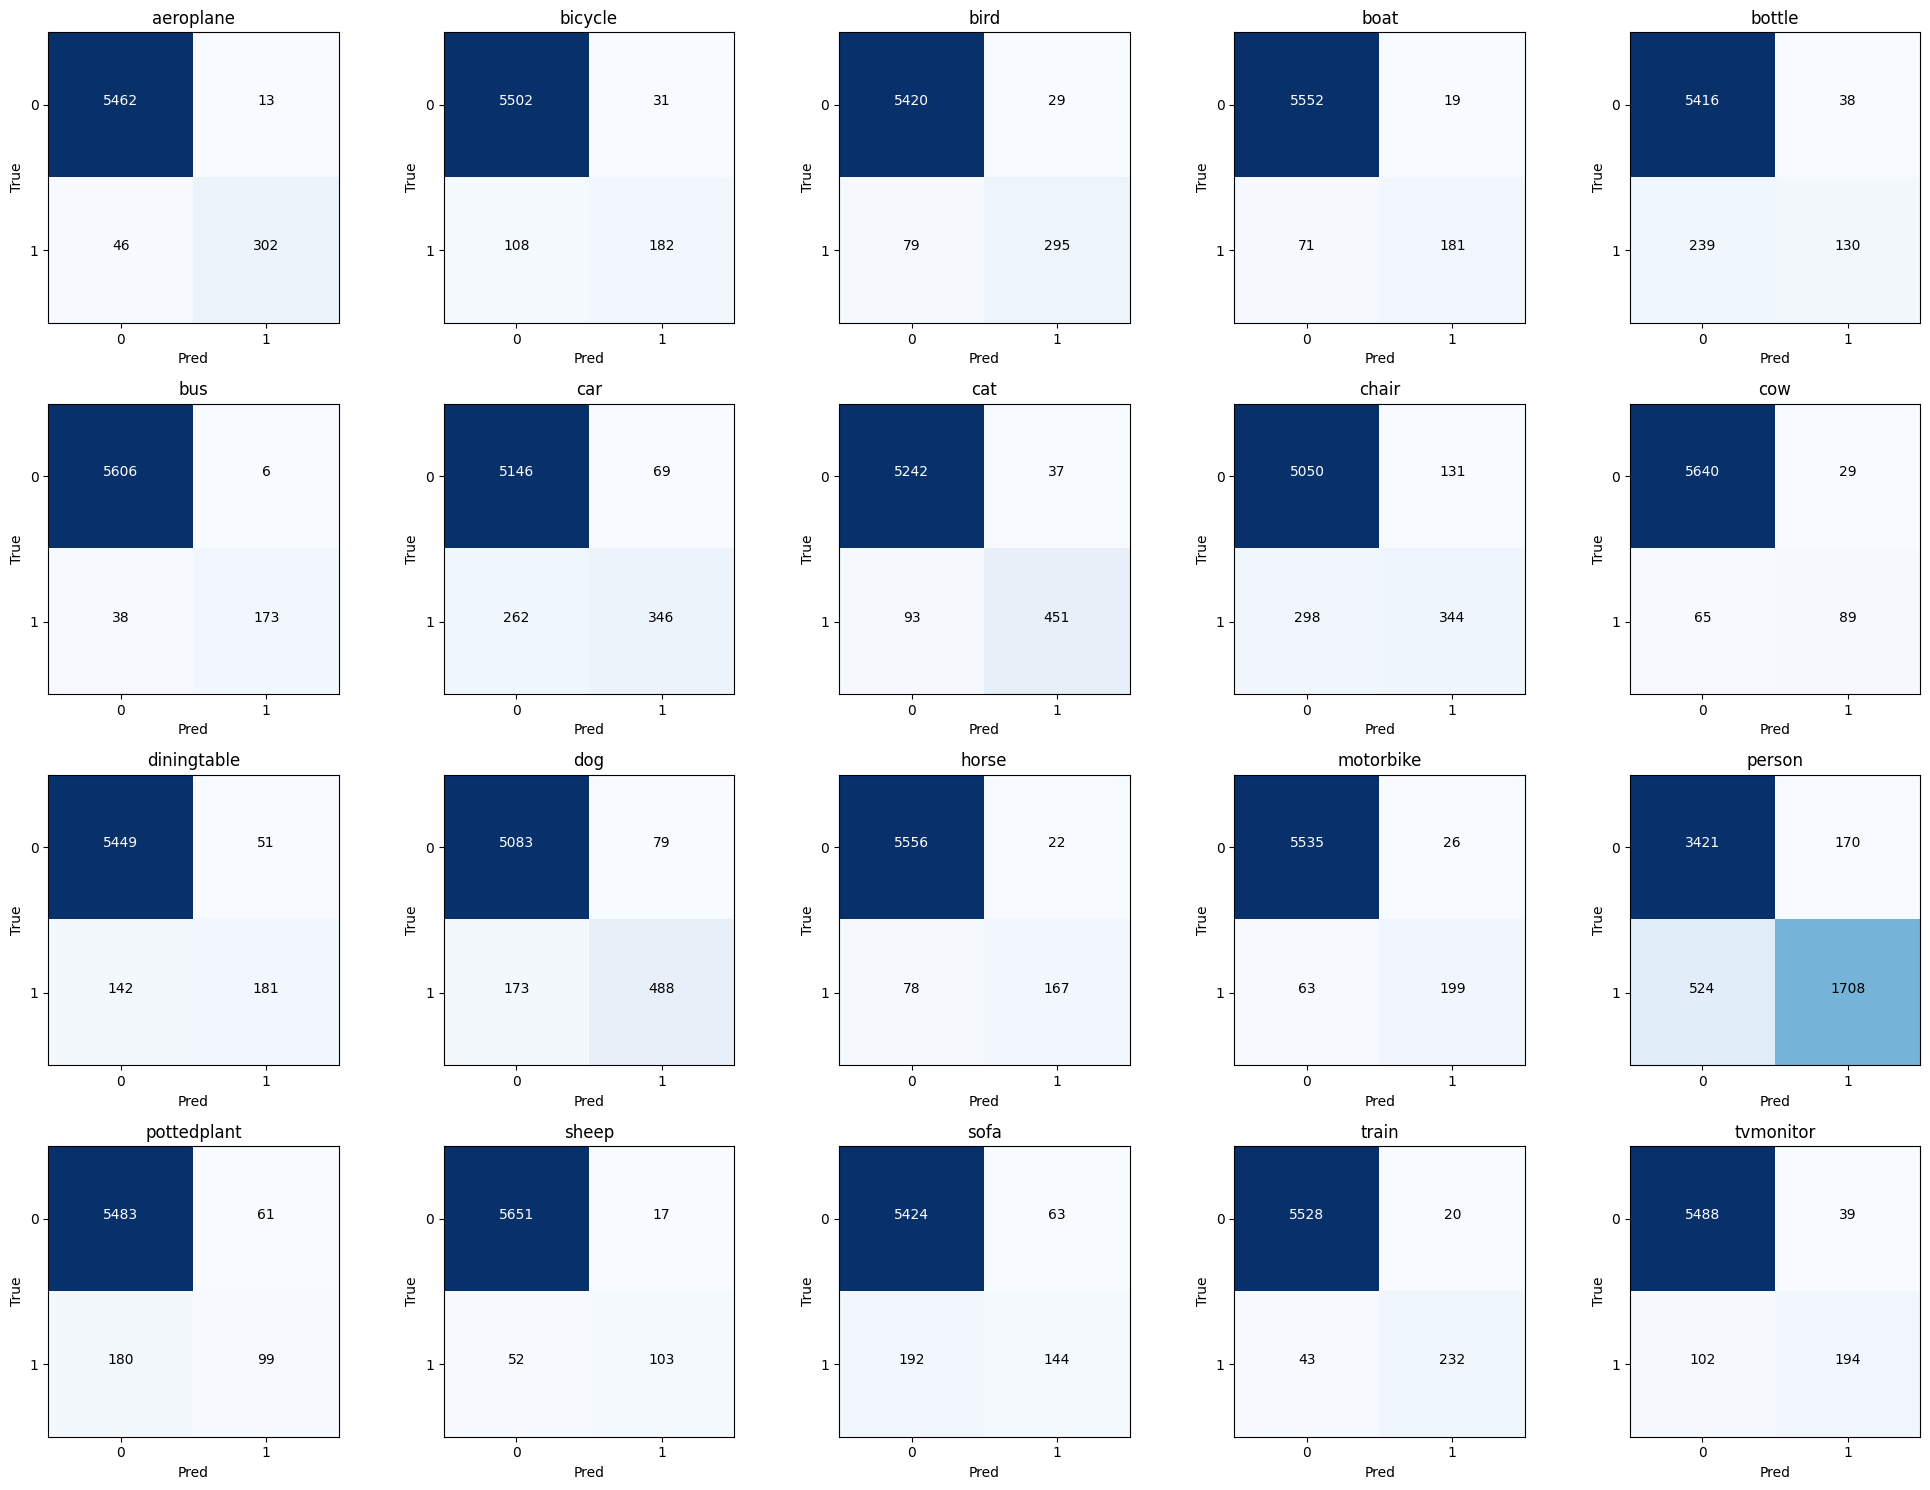

✅ Model saved as mobilenet_voc.h5


In [ ]:
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import numpy as np
import itertools
from sklearn.metrics import multilabel_confusion_matrix

# === Load Pascal VOC 2012 ===
(ds_train, ds_val), ds_info = tfds.load(
    "voc/2012",
    split=["train", "validation"],
    with_info=True
)

NUM_CLASSES = ds_info.features["labels"].num_classes  # 20
CLASS_NAMES = ds_info.features["labels"].names
IMG_SIZE = 224
BATCH_SIZE = 32

# === Preprocess (multi-hot encode labels) ===
def preprocess(example):
    image = tf.image.resize(example["image"], (IMG_SIZE, IMG_SIZE)) / 255.0
    labels = tf.reduce_sum(tf.one_hot(example["labels"], NUM_CLASSES), axis=0)
    return image, labels

train_data = ds_train.map(preprocess).shuffle(1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_data = ds_val.map(preprocess).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# === Custom F1-score Metric ===
class F1Score(tf.keras.metrics.Metric):
    def __init__(self, name="f1_score", threshold=0.5, **kwargs):
        super(F1Score, self).__init__(name=name, **kwargs)
        self.threshold = threshold
        self.precision = tf.keras.metrics.Precision(thresholds=threshold)
        self.recall = tf.keras.metrics.Recall(thresholds=threshold)

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_pred = tf.cast(y_pred > self.threshold, tf.float32)
        self.precision.update_state(y_true, y_pred, sample_weight)
        self.recall.update_state(y_true, y_pred, sample_weight)

    def result(self):
        p = self.precision.result()
        r = self.recall.result()
        return 2 * ((p * r) / (p + r + tf.keras.backend.epsilon()))

    def reset_states(self):
        self.precision.reset_states()
        self.recall.reset_states()

# === Confusion Matrix Callback (only once at end of training) ===
class ConfusionMatrixCallback(tf.keras.callbacks.Callback):
    def __init__(self, val_data, class_names, threshold=0.5):
        super().__init__()
        self.val_data = val_data
        self.class_names = class_names
        self.threshold = threshold

    def on_train_end(self, logs=None):
        y_true = []
        y_pred = []

        for x, y in self.val_data:
            preds = self.model.predict(x, verbose=0)
            preds = (preds > self.threshold).astype(int)
            y_true.append(y.numpy())
            y_pred.append(preds)

        y_true = np.vstack(y_true)
        y_pred = np.vstack(y_pred)

        cm = multilabel_confusion_matrix(y_true, y_pred)

        # Plot per-class confusion matrices (20 subplots, 4x5 grid)
        fig, axes = plt.subplots(4, 5, figsize=(20, 15))
        axes = axes.ravel()

        for i, (ax, cmat) in enumerate(zip(axes, cm)):
            ax.imshow(cmat, interpolation="nearest", cmap=plt.cm.Blues)
            ax.set_title(self.class_names[i])
            tick_marks = np.arange(2)
            ax.set_xticks(tick_marks)
            ax.set_yticks(tick_marks)
            ax.set_xticklabels(["0", "1"])
            ax.set_yticklabels(["0", "1"])
            ax.set_ylabel("True")
            ax.set_xlabel("Pred")

            # Label each cell
            for j, k in itertools.product(range(cmat.shape[0]), range(cmat.shape[1])):
                ax.text(k, j, format(cmat[j, k], "d"),
                        horizontalalignment="center",
                        color="white" if cmat[j, k] > cmat.max() / 2 else "black")

        plt.tight_layout()
        plt.show()

# === MobileNetV2 Model ===
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights="imagenet"
)
base_model.trainable = False

model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(NUM_CLASSES, activation="sigmoid")  # sigmoid for multi-label
])

# === Compile with extra metrics ===
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.AUC(name="auc"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        F1Score(name="f1")
    ]
)

# === Train with final confusion matrix callback ===
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=50,
    callbacks=[ConfusionMatrixCallback(val_data, CLASS_NAMES)]
)

# === Save model ===
model.save("mobilenet_voc.h5")
print("✅ Model saved as mobilenet_voc.h5")


🔹 Raw scores: [7.3052608e-05 1.8155092e-02 7.4322056e-03 2.1253959e-03 5.4533514e-03
 9.9499172e-01 5.1566750e-01 5.2080485e-03 2.9737358e-03 5.2460628e-03
 5.9971712e-03 7.1530053e-03 2.3987689e-03 1.6480284e-02 7.2244287e-01
 3.3654895e-02 2.3422819e-03 8.8473747e-04 2.2275301e-03 3.8072567e-03]
✅ Predicted label: bus (Confidence: 0.9950)


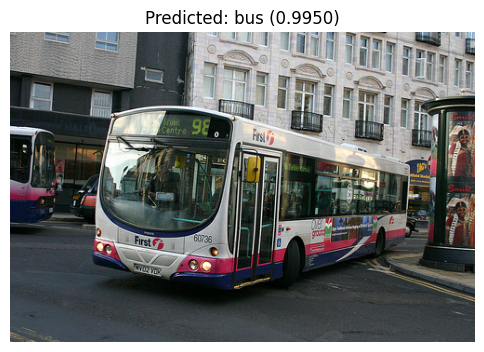

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# === Load labels for Pascal VOC ===
CLASS_NAMES = [
    "aeroplane", "bicycle", "bird", "boat", "bottle",
    "bus", "car", "cat", "chair", "cow",
    "diningtable", "dog", "horse", "motorbike", "person",
    "pottedplant", "sheep", "sofa", "train", "tvmonitor"
]

IMG_SIZE = 224

# === Load trained model ===
model = tf.keras.models.load_model("mobilenet_voc.h5")

# === Prediction Function ===
def predict_image(image_path):
    # Load and preprocess image
    img_raw = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img_raw, channels=3)
    img_resized = tf.image.resize(img, (IMG_SIZE, IMG_SIZE)) / 255.0
    img_input = tf.expand_dims(img_resized, 0)  # add batch dimension

    # Predict
    preds = model.predict(img_input, verbose=0)[0]  # shape (20,)

    # Find the index of the highest score
    max_score_index = np.argmax(preds)
    predicted_label = CLASS_NAMES[max_score_index]
    confidence_score = preds[max_score_index]

    print("🔹 Raw scores:", preds)
    print(f"✅ Predicted label: {predicted_label} (Confidence: {confidence_score:.4f})")


    # === Show image with predictions ===
    plt.figure(figsize=(6, 6))
    plt.imshow(img.numpy().astype("uint8"))
    plt.axis("off")
    plt.title(f"Predicted: {predicted_label} ({confidence_score:.4f})")
    plt.show()

    return predicted_label, confidence_score

# === Example usage ===
test_image ="/content/2011_000559.jpg"  # change path as needed
predicted_label, confidence_score = predict_image(test_image)